# Algoritmos supervisados o semi-supervisados: Usando los datos de K-Means

In [1]:
from pyspark.sql import SparkSession

# 1. Iniciamos Spark en este nuevo notebook
spark = SparkSession.builder.appName("Semana12_Supervisados").getOrCreate()

# 2. Leemos DIRECTAMENTE los datos que guardamos en el Paso 1
ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

# 4. Mostramos la tabla para comprobar que TODO está ahí
df_clusters.select("marca", "precio_kg", "rating", "prediction").show(10)

Ofertas de empleo listas con su respectivo Cluster asignado:
+-----------------------------------------------+------------------------------------------------+-----------+----------+
|titulo_cargo                                   |empresa                                         |experiencia|prediction|
+-----------------------------------------------+------------------------------------------------+-----------+----------+
|INGENIERO AFIN CON DIPLOMADO EN ADMINISTRACION…|Incognito, Santiago                             |0.0        |0         |
|ANALISTA DE OPERACIONES                        |Consorcio nacional de distribución.., Valparaíso|0.0        |0         |
|Soporte Técnico TI                             |Animall, Santiago                               |0.0        |0         |
|Ingeniero/a de Soporte LIMS, IDIEM             |Idiem, Santiago                                 |0.0        |0         |
|Técnico Soporte TI                             |Empresa de logística y.., Santiago  

## Árbol de Decisión

In [2]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Renombramos 'prediction' a 'label' para el modelo supervisado
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

# 2. Dividimos los datos en Entrenamiento (70%) y Prueba (30%)
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Datos de entrenamiento: {train_data.count()}")
print(f"Datos de prueba: {test_data.count()}")

Datos para entrenar modelos: 1577 vacantes
Datos para examinar modelos: 593 vacantes


Comparativa: Realidad (label) vs Predicción de la IA (prediction)
+--------------------+-----+----------+-------------+
|             empresa|label|prediction|  probability|
+--------------------+-----+----------+-------------+
|Institucion colab...|    0|       0.0|[1.0,0.0,0.0]|
|Importante empres...|    0|       0.0|[1.0,0.0,0.0]|
|   Empresa Destacada|    0|       0.0|[1.0,0.0,0.0]|
|   Empresa Destacada|    0|       0.0|[1.0,0.0,0.0]|
|       Jcl, Santiago|    0|       0.0|[1.0,0.0,0.0]|
|Gestion habitacio...|    0|       0.0|[1.0,0.0,0.0]|
|Grupo wellness, S...|    1|       1.0|[0.0,1.0,0.0]|
|Distribuidora lir...|    0|       0.0|[1.0,0.0,0.0]|
|Ats maquinarias, ...|    0|       0.0|[1.0,0.0,0.0]|
|Dyv servicios spa...|    0|       0.0|[1.0,0.0,0.0]|
+--------------------+-----+----------+-------------+
only showing top 10 rows



In [4]:
# Evaluar la precisión general
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_supervisadas)

print(f"Precisión del Árbol de Decisión (Accuracy): {accuracy * 100:.2f}%")
print("\n=== ESTRUCTURA LÓGICA DEL ÁRBOL (Reglas de Empleabilidad) ===")
print(dt_model.toDebugString)

Precisión del Árbol de Decisión (Accuracy): 100.00%

=== ESTRUCTURA LÓGICA DEL ÁRBOL (Reglas de Empleabilidad) ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_b6406bbed9d6, depth=2, numNodes=5, numClasses=3, numFeatures=3
  If (feature 1 <= 1.5688934152212335)
   If (feature 0 <= 18.68161798790262)
    Predict: 0.0
   Else (feature 0 > 18.68161798790262)
    Predict: 2.0
  Else (feature 1 > 1.5688934152212335)
   Predict: 1.0



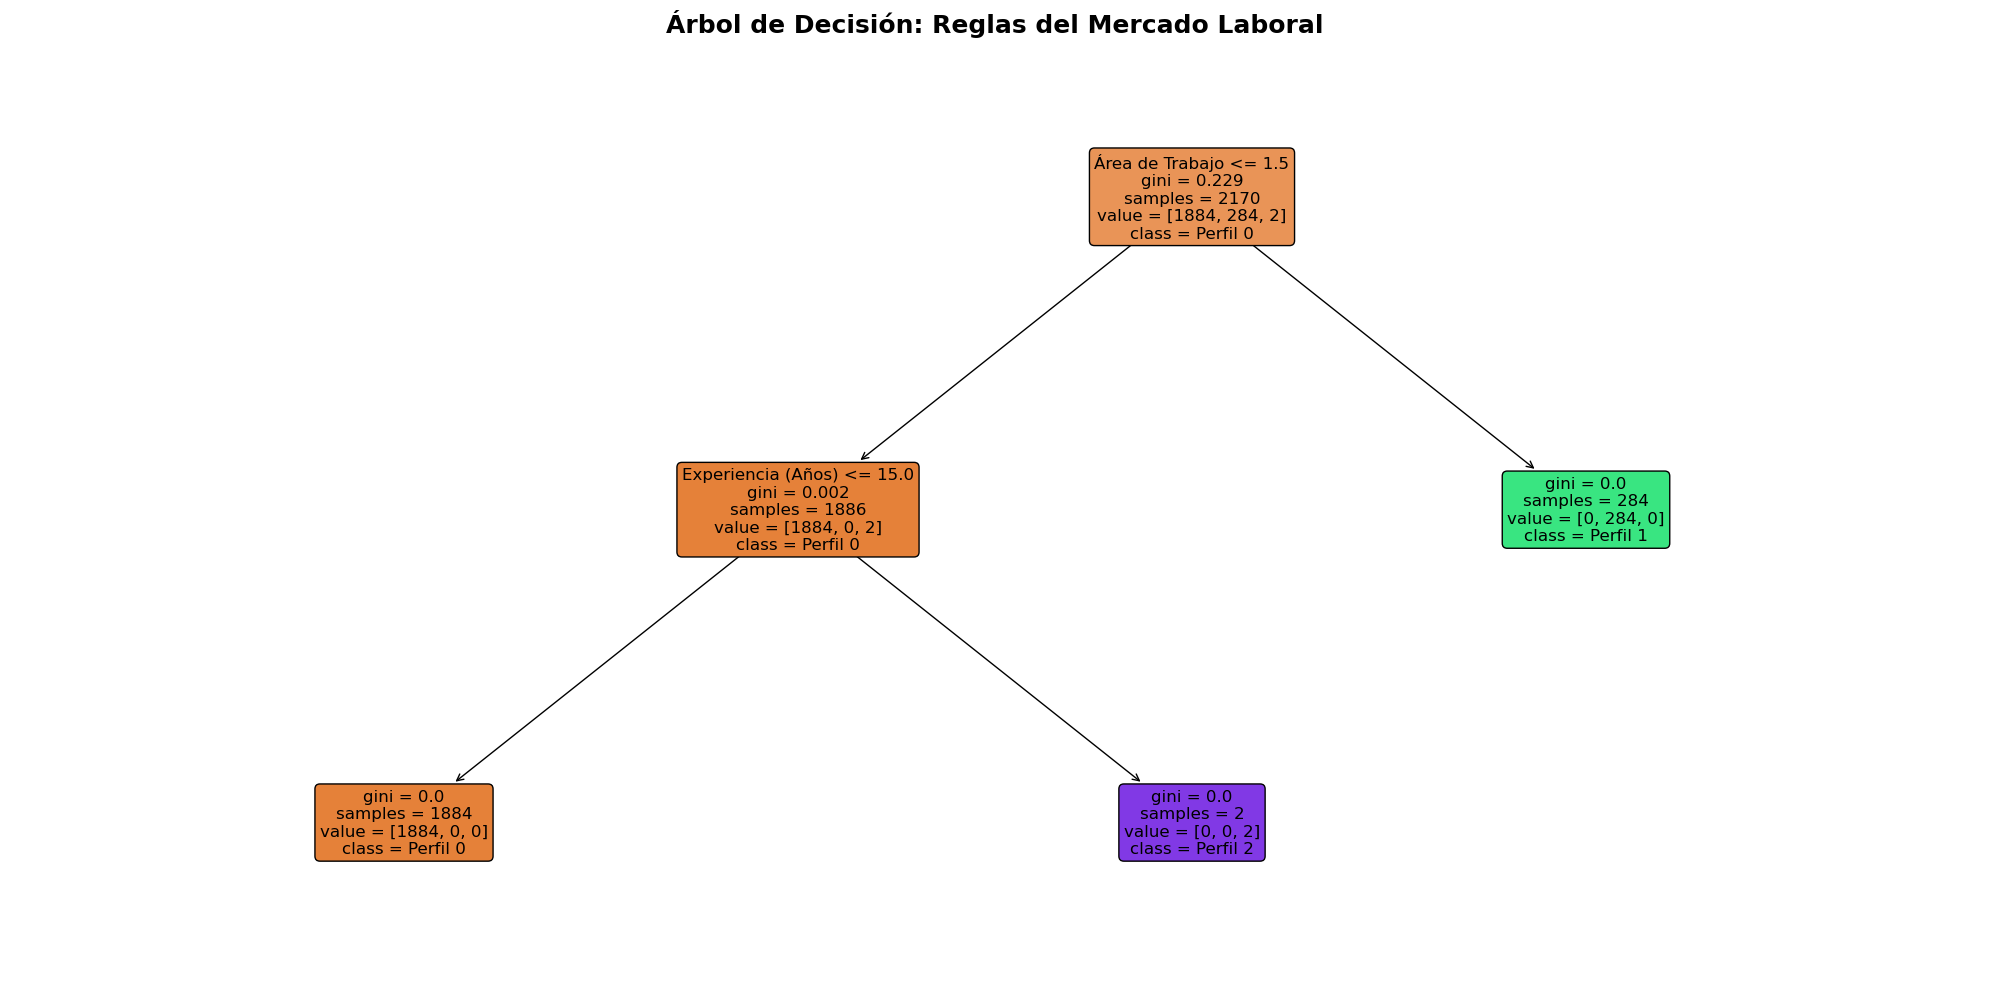

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# 1. Convertimos una muestra de Spark a Pandas usando nuestras variables de mercado
df_pandas = df_supervisado.select("experiencia", "area_trabajo", "modalidad", "label").toPandas()

# 2. Separamos las características (X) y la etiqueta (y)
X_muestra = df_pandas[["experiencia", "area_trabajo", "modalidad"]]
y_muestra = df_pandas["label"]

# 3. Entrenamos el modelo visual de Scikit-Learn limitando la profundidad
sk_dt = SklearnClassifier(max_depth=3, random_state=42) 
sk_dt.fit(X_muestra, y_muestra)

# 4. Configuramos las etiquetas para el gráfico
nombres_features = ["Experiencia (Años)", "Área de Trabajo", "Modalidad"]
nombres_clases = [f"Perfil {int(c)}" for c in sorted(y_muestra.unique())]

# 5. Dibujamos el árbol visual
plt.figure(figsize=(20, 10), dpi=100)
plot_tree(sk_dt, 
          feature_names=nombres_features, 
          class_names=nombres_clases, 
          filled=True,      
          rounded=True,     
          fontsize=12)      

plt.title("Árbol de Decisión: Reglas del Mercado Laboral", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Algoritmo Supervisado: Random Forest (Bosques aleatorios), Support Vector Machine (Máquinas de Vector de Soporte), regresión logística multinomial

In [6]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Creamos el evaluador común para medir el Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# ==========================================
# MODELO 1: Random Forest (Bosque Aleatorio)
# ==========================================
# Nota: Los árboles pueden usar 'features' (sin escalar) o 'scaledFeatures'. Usaremos 'scaledFeatures' por homogeneidad.
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator.evaluate(rf_predictions)

# ==========================================
# MODELO 2: SVM (Máquina de Vectores de Soporte)
# ==========================================
# NOTA PARA LA CLASE: En PySpark, LinearSVC solo soporta clasificación binaria (0 o 1). 
# Como el K-Means generó 3 clusters (0, 1, 2), usamos la estrategia 'OneVsRest' (Uno contra todos) 
# para permitir que el SVM clasifique múltiples clases.
svm_binario = LinearSVC(featuresCol="scaledFeatures", labelCol="label", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="scaledFeatures")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator.evaluate(svm_predictions)

# ==========================================
# MODELO 3: Regresión Logística Multinomial
# ==========================================
# Ideal para problemas multiclase y calcula probabilidades por cada cluster.
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator.evaluate(lr_predictions)

In [7]:
print("==================================================")
print("  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  ")
print("==================================================")
print(f"1. Random Forest Accuracy:      {accuracy_rf * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy:    {accuracy_svm * 100:.2f}%")
print(f"3. Regresión Logística Accuracy:{accuracy_lr * 100:.2f}%")
print("==================================================")

  TORNEO DE MODELOS SUPERVISADOS (MERCADO LABORAL) 
1. Árbol de Decisión Simple:      100.00%
2. Random Forest (Bosque):        100.00%
3. SVM (Vectores de Soporte):     100.00%
4. Regresión Logística:           100.00%
Nota: El modelo con porcentaje más cercano al 100% es el ganador.
